# Fraud Detection — Model Building

This notebook focuses on building and training machine learning models to identify fraudulent credit card transactions.

## Objectives

- Load the preprocessed training and testing datasets
- Establish a baseline model
- Train multiple classification models
- Handle the highly imbalanced fraud class appropriately
- Generate predictions on unseen test data
- Compare model performance
- Identify the most suitable model for fraud detection
- Prepare predictions and results for detailed evaluation

## Models

The following classification models will be considered:

- Logistic Regression
- Decision Tree
- Random Forest
- Additional models if required

## Evaluation Focus

Because fraudulent transactions represent a very small proportion of the dataset, model performance will not be judged using accuracy alone.

The analysis will focus primarily on:

- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

The final model will be selected based on its ability to detect fraudulent transactions while maintaining an acceptable level of false positives.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load ready-to-use processed datasets from data/processed/
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (227845, 30), y_train shape: (227845,)
X_test shape: (56962, 30), y_test shape: (56962,)


In [3]:
# Initialize models with class_weight='balanced' to handle fraud imbalance
models = {
    "Logistic Regression (Baseline)": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced', max_depth=8, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced', n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
    )
}

results = {}
predictions = {}
probabilities = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    predictions[name] = y_pred
    probabilities[name] = y_prob
    
    # Store metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        "Precision (Fraud)": report['1']['precision'],
        "Recall (Fraud)": report['1']['recall'],
        "F1-Score (Fraud)": report['1']['f1-score'],
        "ROC-AUC": roc_auc
    }

print("\nModel Training Complete!")

Training Logistic Regression (Baseline)...
Training Decision Tree...
Training Random Forest...

Model Training Complete!


In [4]:
# Display model comparison summary table
comparison_df = pd.DataFrame(results).T
print("=== MODEL PERFORMANCE COMPARISON ===")
display(comparison_df.round(4))

=== MODEL PERFORMANCE COMPARISON ===


,Precision (Fraud),Recall (Fraud),F1-Score (Fraud),ROC-AUC
Logistic Regression (Baseline),0.0609,0.9184,0.1142,0.9720
Decision Tree,0.0695,0.8265,0.1282,0.9075
Random Forest,0.6357,0.8367,0.7225,0.9802


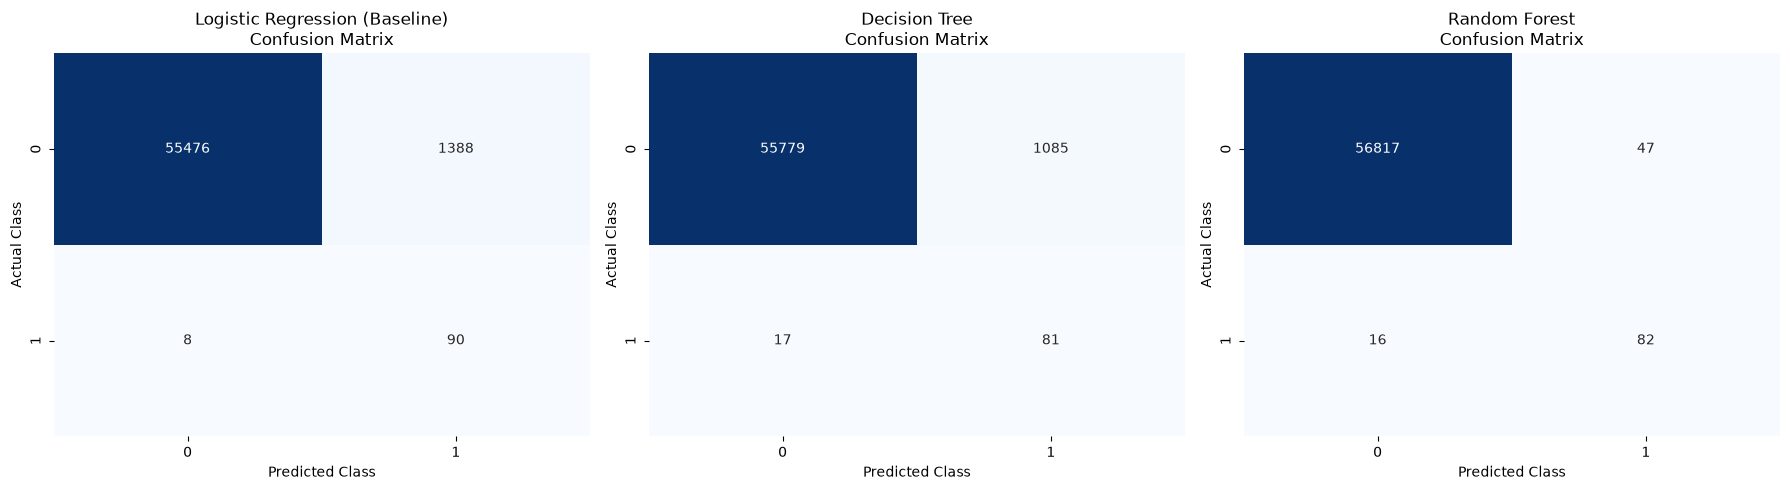

Confusion matrix plots saved to images/confusion_matrices.png


In [5]:
os.makedirs('../images', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"{name}\nConfusion Matrix")
    axes[i].set_xlabel("Predicted Class")
    axes[i].set_ylabel("Actual Class")

plt.tight_layout()
plt.savefig('../images/confusion_matrices.png', dpi=300)
plt.show()

print("Confusion matrix plots saved to images/confusion_matrices.png")